In [49]:
import pathlib
from dataset_writing import *
from experiment import *
from plots import *
from models import SentenceEncoder
from metrics import *
import pandas as pd

In [50]:
MODELS = {
    "MiniLM-L6": "all-MiniLM-L6-v2",
    "mpnet": "all-mpnet-base-v2",
    "BERT-nli-mean-tokens": "bert-base-nli-mean-tokens",
    "BERT-base-uncased": "bert-base-uncased",
    "BERT-base-cased": "bert-base-cased",
    "RoBERTa": "all-roberta-large-v1",
    "MiniLM-L12": "all-MiniLM-L12-v2",
    "e5-small": "intfloat/e5-small",
    "unsup-simcse-bert": "princeton-nlp/unsup-simcse-bert-base-uncased",
    "MathBERT": "tbs17/mathbert",
    "LLM2VEC": "McGill-NLP/LLM2Vec-Sheared-LLaMA-mntp-unsup-simcse",
    "BERT-nli-cls-token": "bert-base-nli-cls-token",
    "nli-mean-numeric-triplet": "nli-mean-numeric-triplet",
    "bert-plain-triplet": "bert-plain-triplet",
    "bert-base-ages_digits": "bert-base-ages_digits",
    "bert-base_ages+full": "bert-base_ages+full",
    "bert-MNRL": "bert-MNRL",
    "bert_MNRL_digits": "bert_MNRL_digits",
    "bert_MNRL_digits+full": "bert_MNRL_digits+full",
    "bert_MNRL_ACS": "bert_MNRL_ACS",
    "msmarco" : "msmarco-distilbert-cos-v5",
    "distilbert": "distilbert-base-uncased"
}

In [51]:
model_name = MODELS["distilbert"]
safe_name = model_name.replace("/", "-")
AGE_RANGE = range(0, 100)
PCA_DIMS = 30
TSNE_PERPLEXITY = 5 # check the method to define the best perplexity.

In [52]:
encoder = SentenceEncoder(model_name)

No sentence-transformers model found with name distilbert-base-uncased. Creating a new one with mean pooling.


In [53]:
DATASET_FILE = pathlib.Path(f"../data/cleaned_data.csv")
out_dir = pathlib.Path(f"../results/full_ACS/{model_name}")
out_dir.mkdir(parents=True, exist_ok=True)

In [54]:
row_num = -1
sentences = load_bigger_dataset(path=DATASET_FILE, row_num=row_num) 

Number of sentences: 100
['the age is 65.0, the class of worker is Employee of a private for-profit company or business, or of an individual, for wages, salary, or commissions, the educational attainment is 1 or more years of college credit but no degree, the marital status is Widowed, the occupation is SAL-Sales Representatives, Wholesale And Manufacturing, the place of birth is Alabama/AL, the relationship is Reference person, the usual hours worked per week past 12 months is 16.0, the sex is Female', 'the age is 57.0, the class of worker is Employee of a private for-profit company or business, or of an individual, for wages, salary, or commissions, the educational attainment is Regular high school diploma, the marital status is Married, the occupation is PRD-Dental And Ophthalmic Laboratory Technicians And Medical Appliance Technicians, the place of birth is Florida/FL, the relationship is Husband/wife, the usual hours worked per week past 12 months is 40.0, the sex is Male', 'the a

In [55]:
results = run_experiment_full(encoder, csv_path=DATASET_FILE, sentences=sentences, max_queries=100)

In [56]:
print(results["accuracy"])
print(results["gold"])
print(results["pred"])

0.9
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 14, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 67, 30, 31, 32, 37, 34, 35, 36, 37, 38, 39, 40, 41, 32, 43, 84, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 44, 56, 57, 58, 59, 60, 61, 62, 26, 64, 65, 66, 73, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 26, 88, 89, 90, 91, 92, 77, 94, 95, 96, 97, 98, 99]


In [57]:
print(results["correct"])

[True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, False, True, True, True, True, True, True, True, True, False, True, False, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, False, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, True]


In [58]:
print(sentences[8])

the age is 62.0, the class of worker is Employee of a private for-profit company or business, or of an individual, for wages, salary, or commissions, the educational attainment is Masters degree, the marital status is Married, the occupation is MGR-General And Operations Managers, the place of birth is Alaska/AK, the relationship is Reference person, the usual hours worked per week past 12 months is 50.0, the sex is Male


In [59]:
print(results["queries"][0])

the age is 65.0, the class of worker is Employee of a private for-profit company or business, or of an individual, for wages, salary, or commissions, the educational attainment is 1 or more years of college credit but no degree, the marital status is Widowed, the occupation is SAL-Sales Representatives, Wholesale And Manufacturing, the place of birth is Alabama/AL, the relationship is Other nonrelative, the usual hours worked per week past 12 months is 16.0, the sex is Female


In [60]:
safe_name = model_name.replace("/", "-")
df_points = pd.DataFrame({
    "true": results["gold"],
    "pred": results["pred"],
    "correct": results["correct"],
    "queries": results["queries"],
    "pred_sents": results["pred_sents"]
})

csv_path = out_dir / f"{safe_name}_results.csv"
df_points.to_csv(csv_path, index=False)
print("Saved results to {}".format(csv_path))


summary = pd.DataFrame([{
    "model": model_name,
    "accuracy": results["accuracy"],
}])

summary_path = out_dir / f"{safe_name}_summary.csv"
summary.to_csv(summary_path, index=False)

print("Summary saved to {}".format(summary_path))

Saved results to ..\results\full_ACS\distilbert-base-uncased\distilbert-base-uncased_results.csv
Summary saved to ..\results\full_ACS\distilbert-base-uncased\distilbert-base-uncased_summary.csv


In [61]:
def plot_tsne_new(model_name, out_folder, query: str, sentences: List[str], encoder, pca_dims: int, perp: int, tsne_dimensions:int = 2, show_labels: bool = False):
    numbers = list(range(100))
    s_numbers = [str(i) for i in numbers]
    emb_nums = encoder.embed(s_numbers)

    emb_query = encoder.embed([str(query)][0])
    #emb_query = encoder.embed(query_text)
    emb_sentences = encoder.embed(sentences)
    #emb_sentences = encoder.embed(num_sentence)

    model_index = encoder.find_best_index(query, emb_sentences)

    all_embeddings = np.vstack([emb_query, emb_sentences, emb_nums])

    # Apply dimensionality reduction (optional, as it does not take that much time)
    # Important to note! Models such as RoBERTa did take long. Gotta look more into if this actually makes it considerably better
    # Dimensionality reduction did not affect the graphing much.
    pca = PCA(n_components=pca_dims, random_state=42)
    pca_transformed = pca.fit_transform(all_embeddings)

    # Ensuring that perplexity is always within the limits of the shape.
    perplexity = min(perp, pca_transformed.shape[0]-1)
    #perplexity = min(perp, all_embeddings.shape[0] - 1)

    tsne = TSNE(n_components=tsne_dimensions, perplexity=perplexity, random_state=42) # I think specifying the random state helps for replicability? I need to check again.
    coords = tsne.fit_transform(pca_transformed)
    #coords = tsne.fit_transform(all_embeddings)

    query_coord = coords[0]
    sentence_coords = coords[1:1 + len(sentences)]
    #best_coords = coords[1 + len(sentences)]
    all_num_coords = coords[1+len(sentences):]

    numbers = list(range(len(all_num_coords)))

    plt.figure(figsize=(6, 6))
    # plot all sentences


    sc2 = plt.scatter(all_num_coords[:, 0], all_num_coords[:, 1], c=numbers, cmap='OrRd', s=20, alpha=0.6, marker=".", label='Numbers')
    plt.colorbar(sc2, label='Number values')



    plt.scatter(*query_coord, marker='^', s=100, color='black', label=f"query=sentence")
    plt.scatter(*sentence_coords[model_index], marker='X', s=120, color='red', label=f"model best")
    #plt.scatter(*best_coords, marker='s', s=120, color='green', label=f"true best={true_age}")
    plt.legend()

    plt.title(f"{model_name} t-SNE projection")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.tight_layout()

    filename = f"tsne_{model_name}.png"
    plt.savefig(out_folder / filename)

    plt.show()

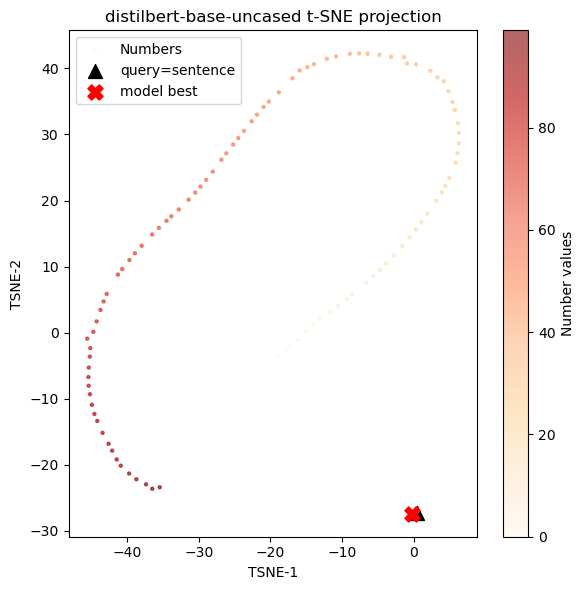

In [62]:
plot_tsne_new(safe_name, out_dir,
          "the age is 19.0, the class of worker is Employee of a private for-profit company or business, or of an individual, for wages, salary, or commissions, the educational attainment is Regular high school diploma, the marital status is Never married or under 15 years old, the occupation is PRD-Sewing Machine Operators, the place of birth is Alabama/AL, the relationship is Biological son or daughter, the usual hours worked per week past 12 months is 32.0, the sex is Female",
          sentences=sentences[:100],
          encoder=encoder,
          pca_dims=PCA_DIMS,
          perp=TSNE_PERPLEXITY,
          show_labels=True
          )